# 01 — Compound Negative-Binomial / Generalised-Pareto loss model

Reproduces the **OEP curve** from §7-8 of the paper. The annual count $N$ is Negative-Binomial; conditional on $N$, the severity per event is Lognormal in the body and GPD in the tail.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dcrisk.frequency.nb_gamma import sample_NB
from dcrisk.severity.lognormal import Lognormal
from dcrisk.severity.gpd import GPD
from dcrisk.severity.mixture import BodyTailMixture
from dcrisk.pricing.pure import pure_premium
from dcrisk.pricing.loadings import sd_premium, esscher_premium, wang_premium

rng = np.random.default_rng(42)

In [2]:
# --- calibrate a body-tail severity from a synthetic dataset ---
n_events = 5_000
body_true = Lognormal(mu=1.5, sigma=0.8)
tail_true = GPD(xi=0.35, sigma=4.0, threshold=20.0)
x_body = body_true.sample(int(0.95 * n_events), rng)
x_tail = tail_true.sample(int(0.05 * n_events), rng)
x = np.concatenate([x_body, x_tail])

mix = BodyTailMixture.fit(x, threshold=20.0)
print('GPD fit: xi=%.3f, sigma=%.3f, p_tail=%.3f' % (mix.tail.xi, mix.tail.sigma, mix.p_tail))

GPD fit: xi=0.324, sigma=4.780, p_tail=0.079


In [3]:
# --- Monte Carlo aggregate loss S ---
nu, lam_bar = 4.0, 6.0
n_sims = 25_000
counts = sample_NB(nu, lam_bar, size=n_sims, rng=rng)
S = np.array([mix.sample(int(c), rng).sum() if c > 0 else 0.0 for c in counts])

print(f'E[S]  = {pure_premium(S):>10,.2f}')
print(f'SD    = {sd_premium(S, 1.0) - pure_premium(S):>10,.2f}')
print(f'Esscher (h=0.001) premium = {esscher_premium(S, 1e-3):>10,.2f}')
print(f'Wang (lam=0.3)    premium = {wang_premium(S, 0.3):>10,.2f}')

E[S]  =      43.25
SD    =      34.23
Esscher (h=0.001) premium =      44.45
Wang (lam=0.3)    premium =      53.67


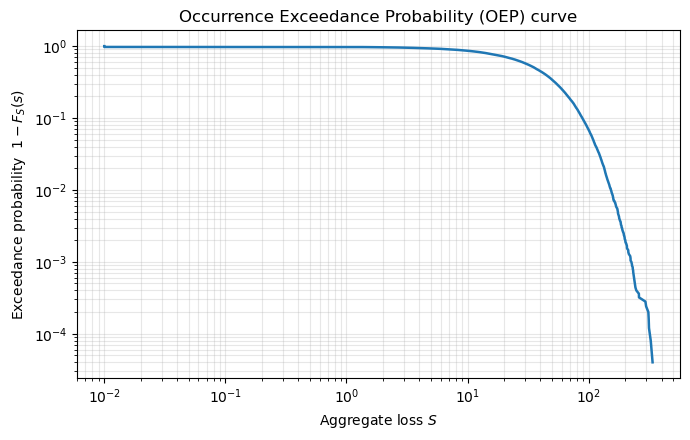

In [4]:
# --- OEP curve (paper Fig. 3 style) ---
S_sorted = np.sort(S)
exceed = 1.0 - np.arange(1, S_sorted.size + 1) / (S_sorted.size + 1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(np.clip(S_sorted, 1e-2, None), exceed, lw=1.8)
ax.set_xlabel('Aggregate loss $S$')
ax.set_ylabel('Exceedance probability  $1 - F_S(s)$')
ax.set_title('Occurrence Exceedance Probability (OEP) curve')
ax.grid(which='both', alpha=0.3)
fig.tight_layout()